# Visualize SCPMNet TPS images

Use this notebook to inspect synthetic TPS image arrays, detection overlays, and TPS `z_surface` maps generated by `src.det.SCPMNet.generate_luna16_tps_images`.

In [28]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

OUTPUT_ROOT = Path("outputs/scpmnet_luna16_10fold_tps_images")
FOLD = 0
MANIFEST = OUTPUT_ROOT / "manifest.csv"

pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.dpi"] = 120

print("manifest:", MANIFEST)
print("exists:", MANIFEST.exists())

manifest: outputs/scpmnet_luna16_10fold_tps_images/manifest.csv
exists: True


In [29]:
df = pd.read_csv(MANIFEST)

for col in ["synthetic_image", "overlay_image", "z_surface"]:
    df[f"{col}_exists"] = df[col].fillna("").map(lambda p: Path(str(p)).exists())

print("rows:", len(df))
print("folds:", sorted(df["fold"].unique().tolist()))
print("anchor grids:", sorted(df["anchor_grid_size"].dropna().unique().tolist()) if "anchor_grid_size" in df else "missing")
print("clip margins:", sorted(df["surface_clip_margin"].dropna().unique().tolist()) if "surface_clip_margin" in df else "missing")
print()
print(df[["synthetic_image_exists", "overlay_image_exists", "z_surface_exists"]].sum())

df.head(3)

rows: 888
folds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
anchor grids: [10]
clip margins: [40.0]

synthetic_image_exists    810
overlay_image_exists      809
z_surface_exists          808
dtype: int64


,fold,seriesuid,image_path,prediction_csv,synthetic_image,overlay_image,z_surface,num_detections,anchor_grid_size,surface_clip_margin,top_probability,mean_detection_z,min_detection_z,max_detection_z,synthetic_image_exists,overlay_image_exists,z_surface_exists
0,0,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260,/ssd2/domenico/datasets/LUNA16_preprocessed/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260...,outputs/scpmnet_luna16_10fold/scpmnet_paper_luna16_fold0/predictions/test_predictions.csv,outputs/scpmnet_luna16_10fold_tps_images/fold_0/1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260_tps...,outputs/scpmnet_luna16_10fold_tps_images/fold_0/1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260_tps...,outputs/scpmnet_luna16_10fold_tps_images/fold_0/1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260_tps...,5,10,40.0,0.592296,155.116362,99.195160,196.937607,True,True,True
1,0,1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492,/ssd2/domenico/datasets/LUNA16_preprocessed/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492...,outputs/scpmnet_luna16_10fold/scpmnet_paper_luna16_fold0/predictions/test_predictions.csv,outputs/scpmnet_luna16_10fold_tps_images/fold_0/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492_tps...,outputs/scpmnet_luna16_10fold_tps_images/fold_0/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492_tps...,outputs/scpmnet_luna16_10fold_tps_images/fold_0/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492_tps...,5,10,40.0,0.774101,106.614358,35.817020,266.185577,True,True,True
2,0,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524522225658609808059,/ssd2/domenico/datasets/LUNA16_preprocessed/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524522225658609808059...,outputs/scpmnet_luna16_10fold/scpmnet_paper_luna16_fold0/predictions/test_predictions.csv,outputs/scpmnet_luna16_10fold_tps_images/fold_0/1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524522225658609808059_tps...,outputs/scpmnet_luna16_10fold_tps_images/fold_0/1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524522225658609808059_tps...,outputs/scpmnet_luna16_10fold_tps_images/fold_0/1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524522225658609808059_tps...,5,10,40.0,0.558641,120.650804,70.993828,166.137131,True,True,True


In [30]:
def load_array(path):
    return np.load(Path(path))


def load_overlay(path):
    return np.asarray(Image.open(Path(path)).convert("RGB"))


def top_detections_for_row(row):
    pred = pd.read_csv(row["prediction_csv"])
    pred["seriesuid"] = pred["seriesuid"].astype(str)
    det = pred[pred["seriesuid"] == str(row["seriesuid"])].copy()
    det = det.sort_values("probability", ascending=False).head(int(row.get("num_detections", 5)))
    return det.reset_index(drop=True)


def robust_limits(image, low=1, high=99):
    lo, hi = np.percentile(image[np.isfinite(image)], [low, high])
    if hi <= lo:
        lo, hi = float(np.nanmin(image)), float(np.nanmax(image))
    return lo, hi


def surface_stats(surface):
    gy, gx = np.gradient(surface)
    return {
        "z_min": float(surface.min()),
        "z_max": float(surface.max()),
        "z_mean": float(surface.mean()),
        "z_std": float(surface.std()),
        "mean_abs_grad_y": float(np.abs(gy).mean()),
        "mean_abs_grad_x": float(np.abs(gx).mean()),
    }


def row_by_index_or_series(index=0, seriesuid=None):
    if seriesuid is not None:
        hits = df[df["seriesuid"].astype(str) == str(seriesuid)]
        if hits.empty:
            raise ValueError(f"seriesuid not found: {seriesuid}")
        return hits.iloc[0]
    return df.iloc[int(index)]

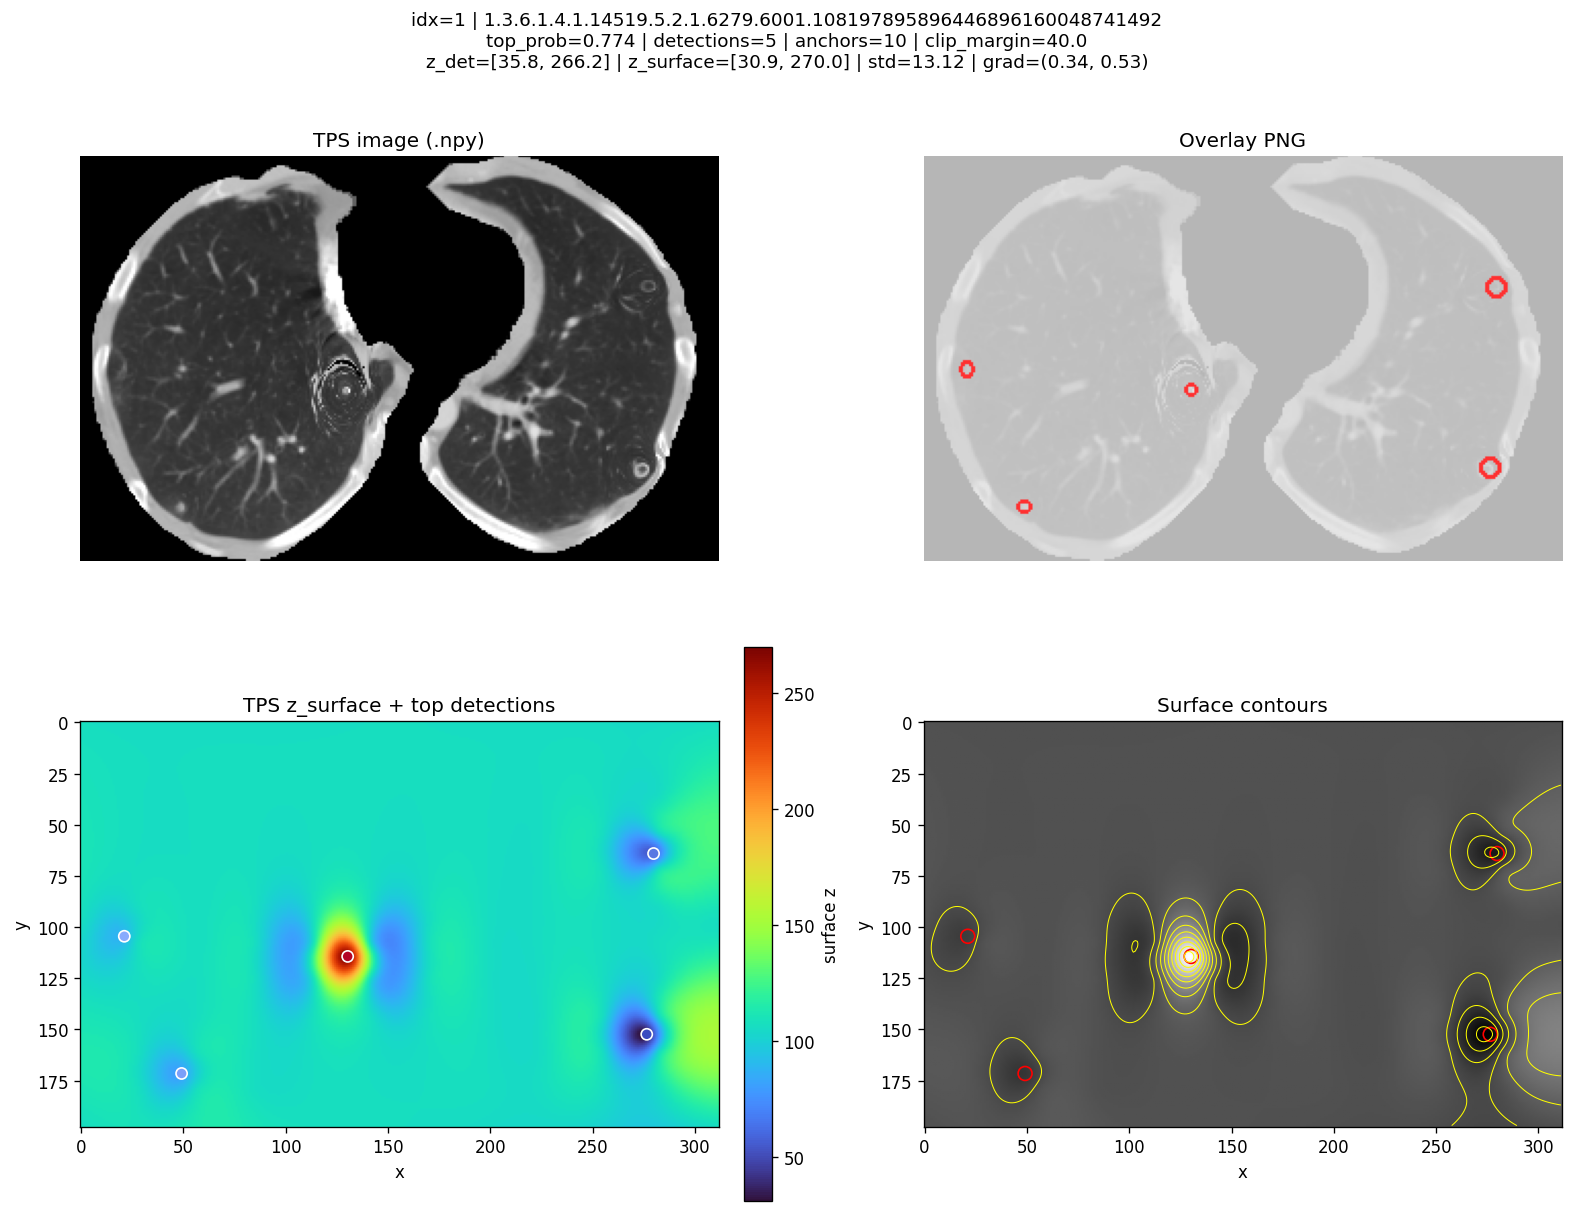

,coordZ,coordY,coordX,radius,probability
0,81.973091,171.535507,49.111610,3.375588,0.774101
1,90.217735,104.480278,21.102980,3.581167,0.587866
2,58.878365,64.050270,279.763245,4.966176,0.528502
3,35.817020,152.386963,276.425079,4.812848,0.490942
4,266.185577,114.327438,130.269043,2.972718,0.453933


In [41]:
def show_case(index=0, seriesuid=None, image_percentiles=(1, 99), surface_contours=12):
    row = row_by_index_or_series(index=index, seriesuid=seriesuid)
    image = load_array(row["synthetic_image"])
    overlay = load_overlay(row["overlay_image"]) if Path(str(row["overlay_image"])).exists() else None
    surface = load_array(row["z_surface"])
    detections = top_detections_for_row(row)
    stats = surface_stats(surface)

    lo, hi = robust_limits(image, *image_percentiles)
    fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)

    axes[0, 0].imshow(image, cmap="gray", vmin=lo, vmax=hi)
    axes[0, 0].set_title("TPS image (.npy)")
    axes[0, 0].axis("off")

    if overlay is not None:
        axes[0, 1].imshow(overlay)
        axes[0, 1].set_title("Overlay PNG")
    else:
        axes[0, 1].imshow(image, cmap="gray", vmin=lo, vmax=hi)
        axes[0, 1].set_title("Overlay missing")
    axes[0, 1].axis("off")

    surf_im = axes[1, 0].imshow(surface, cmap="turbo")
    axes[1, 0].scatter(detections["coordX"], detections["coordY"], c=detections["coordZ"], cmap="coolwarm", edgecolor="white", s=45)
    axes[1, 0].set_title("TPS z_surface + top detections")
    axes[1, 0].set_xlabel("x")
    axes[1, 0].set_ylabel("y")
    plt.colorbar(surf_im, ax=axes[1, 0], fraction=0.046, pad=0.04, label="surface z")

    axes[1, 1].imshow(surface, cmap="gray")
    axes[1, 1].contour(surface, levels=surface_contours, colors="yellow", linewidths=0.6)
    axes[1, 1].scatter(detections["coordX"], detections["coordY"], facecolors="none", edgecolors="red", s=70)
    axes[1, 1].set_title("Surface contours")
    axes[1, 1].set_xlabel("x")
    axes[1, 1].set_ylabel("y")

    title = (
        f"idx={df.index[df['seriesuid'].astype(str) == str(row['seriesuid'])][0]} | {row['seriesuid']}\n"
        f"top_prob={row['top_probability']:.3f} | detections={int(row['num_detections'])} | "
        f"anchors={row.get('anchor_grid_size', 'NA')} | clip_margin={row.get('surface_clip_margin', 'NA')}\n"
        f"z_det=[{row.get('min_detection_z', np.nan):.1f}, {row.get('max_detection_z', np.nan):.1f}] | "
        f"z_surface=[{stats['z_min']:.1f}, {stats['z_max']:.1f}] | std={stats['z_std']:.2f} | "
        f"grad=({stats['mean_abs_grad_y']:.2f}, {stats['mean_abs_grad_x']:.2f})"
    )
    fig.suptitle(title, fontsize=11)
    plt.show()

    display(detections[["coordZ", "coordY", "coordX", "radius", "probability"]])
    return row, stats


_ = show_case(index=1)

GT nodules: 11860 | folds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


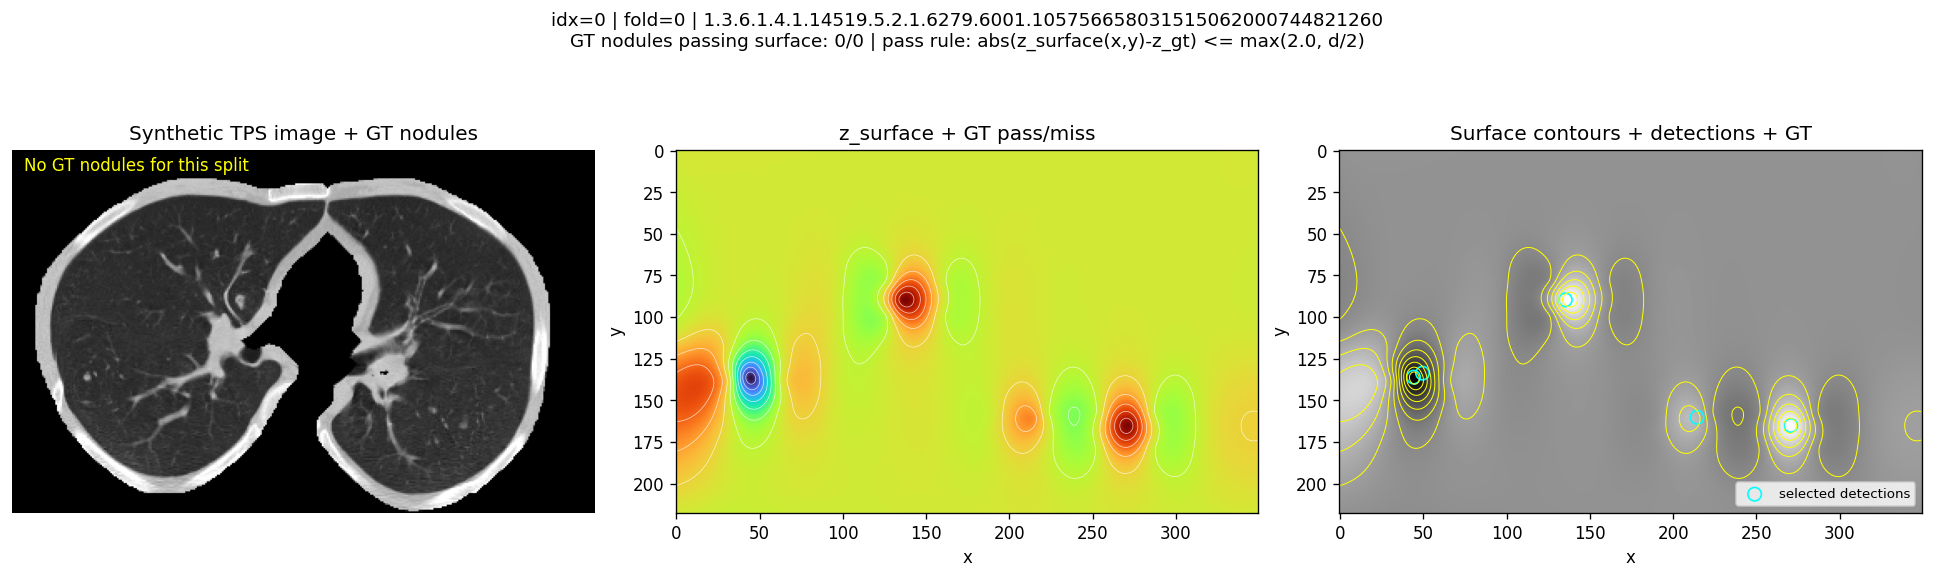

In [53]:
from IPython.display import display

GT_SPLITS_DIR = Path("data/LUNA16_preprocessed/cv_splits")
GT_SPLIT = "test"
CENTER_TOLERANCE_SLICES = 2.0


def load_ground_truth_splits(splits_dir=GT_SPLITS_DIR):
    frames = []
    for split_csv in sorted(Path(splits_dir).glob("luna16_fold*.csv")):
        fold = int(split_csv.stem.replace("luna16_fold", ""))
        fold_df = pd.read_csv(split_csv)
        fold_df["fold"] = fold
        frames.append(fold_df)
    if not frames:
        raise FileNotFoundError(f"No luna16_fold*.csv files found in {splits_dir}")

    gt = pd.concat(frames, ignore_index=True)
    gt["seriesuid"] = gt["seriesuid"].astype(str)
    gt = gt[(gt["label"].astype(str) == "nodule") & gt[["x", "y", "z"]].notna().all(axis=1)].copy()
    gt["radius_z"] = gt["d"].astype(float) / 2.0
    gt["radius_xy"] = gt[["w", "h"]].astype(float).mean(axis=1) / 2.0
    return gt


gt_df = load_ground_truth_splits()
print("GT nodules:", len(gt_df), "| folds:", sorted(gt_df["fold"].unique().tolist()))


def ground_truth_for_row(row, split=GT_SPLIT):
    hits = gt_df[
        (gt_df["fold"].astype(int) == int(row["fold"]))
        & (gt_df["seriesuid"].astype(str) == str(row["seriesuid"]))
    ].copy()
    if split is not None and "split" in hits.columns:
        hits = hits[hits["split"].astype(str) == str(split)].copy()
    return hits.reset_index(drop=True)


def bilinear_surface_z(surface, x, y):
    ny, nx = surface.shape
    if not np.isfinite(x) or not np.isfinite(y) or x < 0 or y < 0 or x > nx - 1 or y > ny - 1:
        return np.nan

    x0 = int(np.floor(x))
    x1 = min(x0 + 1, nx - 1)
    y0 = int(np.floor(y))
    y1 = min(y0 + 1, ny - 1)
    dx = float(x - x0)
    dy = float(y - y0)

    z00 = surface[y0, x0]
    z01 = surface[y0, x1]
    z10 = surface[y1, x0]
    z11 = surface[y1, x1]
    return float((1 - dy) * ((1 - dx) * z00 + dx * z01) + dy * ((1 - dx) * z10 + dx * z11))


def ground_truth_surface_matches(row, tolerance_slices=CENTER_TOLERANCE_SLICES, split=GT_SPLIT):
    surface_path = Path(str(row["z_surface"]))
    gt = ground_truth_for_row(row, split=split)
    if gt.empty:
        return gt.assign(surface_z=[], abs_dz=[], tolerance=[], passes_surface=[])
    if not surface_path.exists():
        out = gt.copy()
        out["surface_z"] = np.nan
        out["abs_dz"] = np.nan
        out["tolerance"] = np.maximum(float(tolerance_slices), out["radius_z"].astype(float))
        out["passes_surface"] = False
        return out

    surface = load_array(surface_path)
    out = gt.copy()
    out["surface_z"] = [bilinear_surface_z(surface, x, y) for x, y in zip(out["x"], out["y"])]
    out["abs_dz"] = (out["surface_z"] - out["z"].astype(float)).abs()
    out["tolerance"] = np.maximum(float(tolerance_slices), out["radius_z"].astype(float))
    out["passes_surface"] = out["abs_dz"] <= out["tolerance"]
    return out


def show_case_with_ground_truth(index=0, seriesuid=None, image_percentiles=(1, 99), tolerance_slices=CENTER_TOLERANCE_SLICES):
    row = row_by_index_or_series(index=index, seriesuid=seriesuid)
    image = load_array(row["synthetic_image"])
    surface = load_array(row["z_surface"])
    detections = top_detections_for_row(row)
    gt = ground_truth_surface_matches(row, tolerance_slices=tolerance_slices)

    lo, hi = robust_limits(image, *image_percentiles)
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

    axes[0].imshow(image, cmap="gray", vmin=lo, vmax=hi)
    axes[0].set_title("Synthetic TPS image + GT nodules")
    axes[0].axis("off")

    axes[1].imshow(surface, cmap="turbo")
    axes[1].contour(surface, levels=12, colors="white", linewidths=0.45, alpha=0.7)
    axes[1].set_title("z_surface + GT pass/miss")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")

    axes[2].imshow(surface, cmap="gray")
    axes[2].contour(surface, levels=12, colors="yellow", linewidths=0.6)
    axes[2].scatter(detections["coordX"], detections["coordY"], facecolors="none", edgecolors="cyan", s=65, label="selected detections")
    axes[2].set_title("Surface contours + detections + GT")
    axes[2].set_xlabel("x")
    axes[2].set_ylabel("y")

    if gt.empty:
        axes[0].text(0.02, 0.98, "No GT nodules for this split", transform=axes[0].transAxes, color="yellow", va="top")
    else:
        for gt_idx, item in gt.iterrows():
            color = "lime" if bool(item["passes_surface"]) else "red"
            marker = "o" if bool(item["passes_surface"]) else "x"
            size = max(70, float(item.get("radius_xy", 3.0)) * 55)
            label = "GT pass" if bool(item["passes_surface"]) else "GT miss"
            label = label if label not in axes[0].get_legend_handles_labels()[1] else None

            axes[0].scatter(item["x"], item["y"], s=size, marker=marker, facecolors="none", edgecolors=color, linewidths=2.0, label=label)
            axes[0].text(item["x"] + 3, item["y"] + 3, f"dz={item['abs_dz']:.1f}", color=color, fontsize=8)
            axes[1].scatter(item["x"], item["y"], s=size, marker=marker, facecolors="none", edgecolors=color, linewidths=2.0)
            axes[2].scatter(item["x"], item["y"], s=size, marker=marker, facecolors="none", edgecolors=color, linewidths=2.0)

    for ax in axes:
        handles, labels = ax.get_legend_handles_labels()
        if labels:
            ax.legend(loc="lower right", fontsize=8)

    idx = df.index[df["seriesuid"].astype(str) == str(row["seriesuid"])][0]
    n_pass = int(gt["passes_surface"].sum()) if not gt.empty else 0
    fig.suptitle(
        f"idx={idx} | fold={int(row['fold'])} | {row['seriesuid']}\n"
        f"GT nodules passing surface: {n_pass}/{len(gt)} | pass rule: abs(z_surface(x,y)-z_gt) <= max({tolerance_slices}, d/2)",
        fontsize=11,
    )
    plt.show()

    if not gt.empty:
        display_cols = ["x", "y", "z", "surface_z", "abs_dz", "radius_z", "tolerance", "passes_surface", "diameter_mm"]
        display(gt[display_cols].sort_values("abs_dz"))
    return row, gt


_ = show_case_with_ground_truth(index=0)


In [33]:
def compute_gt_surface_coverage(frame=df, tolerance_slices=CENTER_TOLERANCE_SLICES, split=GT_SPLIT):
    rows = []
    for idx, row in frame.iterrows():
        if not Path(str(row["z_surface"])).exists():
            continue
        matches = ground_truth_surface_matches(row, tolerance_slices=tolerance_slices, split=split)
        for _, item in matches.iterrows():
            rows.append(
                {
                    "index": idx,
                    "fold": int(row["fold"]),
                    "seriesuid": row["seriesuid"],
                    "x": item["x"],
                    "y": item["y"],
                    "z": item["z"],
                    "surface_z": item["surface_z"],
                    "abs_dz": item["abs_dz"],
                    "radius_z": item["radius_z"],
                    "tolerance": item["tolerance"],
                    "passes_surface": bool(item["passes_surface"]),
                }
            )
    return pd.DataFrame(rows)


gt_surface_coverage = compute_gt_surface_coverage()
print("GT nodules on generated synthetic surfaces:", len(gt_surface_coverage))
if not gt_surface_coverage.empty:
    print("passes surface:", int(gt_surface_coverage["passes_surface"].sum()), "/", len(gt_surface_coverage))
    print("pass rate:", f"{gt_surface_coverage['passes_surface'].mean() * 100:.1f}%")
    display(gt_surface_coverage.sort_values("abs_dz", ascending=False).head(20))


GT nodules on generated synthetic surfaces: 1087
passes surface: 708 / 1087
pass rate: 65.1%


,index,fold,seriesuid,x,y,z,surface_z,abs_dz,radius_z,tolerance,passes_surface
871,717,8,1.3.6.1.4.1.14519.5.2.1.6279.6001.149041668385192796520281592139,223.512663,181.794013,58.207576,303.989929,245.782353,7.996175,7.996175,False
878,722,8,1.3.6.1.4.1.14519.5.2.1.6279.6001.168833925301530155818375859047,259.762393,67.501197,71.192040,271.599945,200.407905,3.607914,3.607914,False
996,807,9,1.3.6.1.4.1.14519.5.2.1.6279.6001.124822907934319930841506266464,198.987905,172.912138,297.579702,98.115044,199.464659,1.696993,2.000000,False
553,394,4,1.3.6.1.4.1.14519.5.2.1.6279.6001.230416590143922549745658357505,51.851921,81.485842,260.864243,62.201775,198.662468,2.068939,2.068939,False
937,760,8,1.3.6.1.4.1.14519.5.2.1.6279.6001.288701997968615460794642979503,42.152886,179.169973,96.133036,292.716278,196.583242,2.805954,2.805954,False
938,760,8,1.3.6.1.4.1.14519.5.2.1.6279.6001.288701997968615460794642979503,296.345004,130.210034,96.547346,292.725189,196.177843,2.319673,2.319673,False
295,214,2,1.3.6.1.4.1.14519.5.2.1.6279.6001.217589936421986638139451480826,126.610883,115.650328,270.419037,74.327271,196.091766,3.006007,3.006007,False
966,786,8,1.3.6.1.4.1.14519.5.2.1.6279.6001.675543413149938600000570588203,50.153613,48.938137,85.906781,277.541534,191.634753,2.438840,2.438840,False
864,712,8,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860,26.978313,105.358463,131.012487,321.181732,190.169245,2.825735,2.825735,False
877,722,8,1.3.6.1.4.1.14519.5.2.1.6279.6001.168833925301530155818375859047,288.369273,126.852125,85.337976,271.569061,186.231085,2.330997,2.330997,False


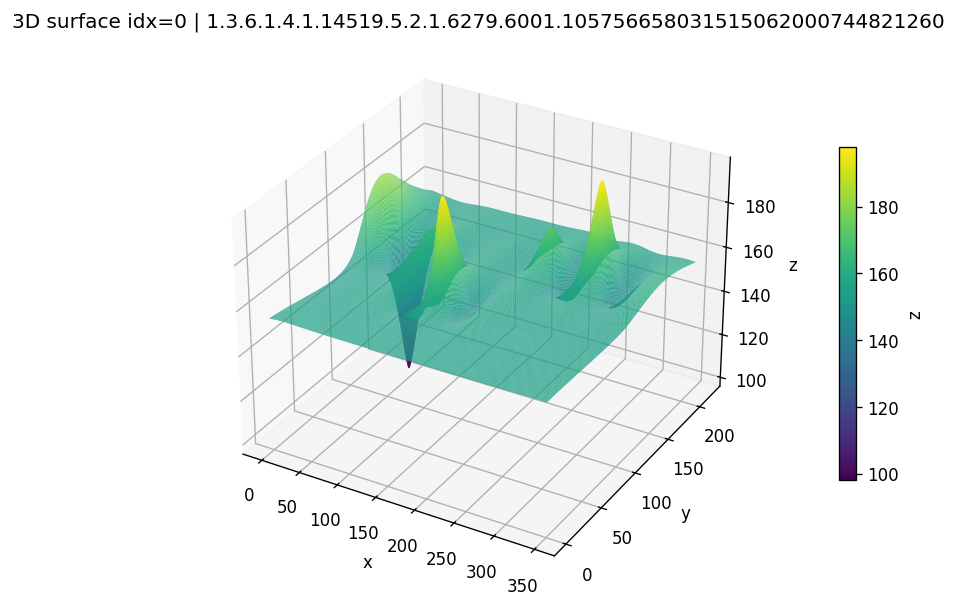

fold                                                                                                                                            0
seriesuid                                                                        1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260
image_path                /ssd2/domenico/datasets/LUNA16_preprocessed/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260...
prediction_csv                                          outputs/scpmnet_luna16_10fold/scpmnet_paper_luna16_fold0/predictions/test_predictions.csv
synthetic_image           outputs/scpmnet_luna16_10fold_tps_images/fold_0/1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260_tps...
overlay_image             outputs/scpmnet_luna16_10fold_tps_images/fold_0/1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260_tps...
z_surface                 outputs/scpmnet_luna16_10fold_tps_images/fold_0/1.3.6.1.4.1.14519.5.2.1.6279.6001.1057566580315150

In [52]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def plot_surface_3d(index=0, seriesuid=None, stride=1, cmap="viridis", elev=30, azim=-60):
    row = row_by_index_or_series(index=index, seriesuid=seriesuid)
    surface = load_array(row["z_surface"])
    ny, nx = surface.shape
    X, Y = np.meshgrid(np.arange(nx), np.arange(ny))

    fig = plt.figure(figsize=(9, 6))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(X, Y, surface, rstride=stride, cstride=stride, cmap=cmap, linewidth=0, antialiased=True)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.view_init(elev=elev, azim=azim)
    plt.title(f"3D surface idx={df.index[df['seriesuid'].astype(str) == str(row['seriesuid'])][0]} | {row['seriesuid']}")
    fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label="z")
    plt.show()
    return row

# Auto-run using the interactive slider if available, otherwise index 0
plot_surface_3d(index=0)


In [50]:
# Optional interactive browser. If ipywidgets is unavailable, use show_case(index=...) manually.
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    slider = widgets.IntSlider(value=0, min=0, max=len(df) - 1, step=1, description="index", continuous_update=False)
    out = widgets.Output()

    def on_change(change=None):
        with out:
            clear_output(wait=True)
            show_case(index=slider.value)

    slider.observe(on_change, names="value")
    display(slider, out)
    on_change()
except Exception as exc:
    print("Interactive widgets unavailable:", exc)
    print("Use show_case(index=10) or show_case(seriesuid='...') instead.")

IntSlider(value=0, continuous_update=False, description='index', max=887)

Output()

In [36]:
def add_surface_quality_columns(frame):
    rows = []
    for idx, row in frame.iterrows():
        surface_path = Path(str(row["z_surface"]))
        if not surface_path.exists():
            continue
        surface = load_array(surface_path)
        stats = surface_stats(surface)
        clip_margin = row.get("surface_clip_margin", np.nan)
        det_min = row.get("min_detection_z", np.nan)
        det_max = row.get("max_detection_z", np.nan)
        if pd.notna(clip_margin) and pd.notna(det_min) and pd.notna(det_max):
            lo = max(float(det_min) - float(clip_margin), 0.0)
            hi = float(det_max) + float(clip_margin)
            stats["clip_low_frac"] = float(np.isclose(surface, lo, atol=1e-3).mean())
            stats["clip_high_frac"] = float(np.isclose(surface, hi, atol=1e-3).mean())
        else:
            stats["clip_low_frac"] = np.nan
            stats["clip_high_frac"] = np.nan
        rows.append({"index": idx, "seriesuid": row["seriesuid"], **stats})
    return pd.DataFrame(rows).merge(frame, on="seriesuid", how="left")


quality = add_surface_quality_columns(df)
quality.sort_values("z_std", ascending=False).head(12)[[
    "index", "seriesuid", "z_min", "z_max", "z_mean", "z_std", "mean_abs_grad_y", "mean_abs_grad_x", "clip_low_frac", "clip_high_frac"
]]


,index,seriesuid,z_min,z_max,z_mean,z_std,mean_abs_grad_y,mean_abs_grad_x,clip_low_frac,clip_high_frac
797,877,1.3.6.1.4.1.14519.5.2.1.6279.6001.558286136379689377915919180358,18.255939,280.335571,127.135353,66.914970,1.544403,3.366247,0.128884,0.099694
688,768,1.3.6.1.4.1.14519.5.2.1.6279.6001.302403227435841351528721627052,25.145309,279.000000,194.654251,39.237331,0.975541,1.213936,0.028907,0.000000
344,344,1.3.6.1.4.1.14519.5.2.1.6279.6001.614147706162329660656328811671,13.482655,233.910690,113.069885,38.388485,0.607574,1.651622,0.046782,0.042375
750,830,1.3.6.1.4.1.14519.5.2.1.6279.6001.194632613233275988184244485809,0.000000,250.000000,109.994781,37.945648,1.237437,1.719444,0.032676,0.000000
89,89,1.3.6.1.4.1.14519.5.2.1.6279.6001.100684836163890911914061745866,51.928474,251.382828,167.529480,37.274395,0.850322,1.871130,0.040233,0.071282
249,249,1.3.6.1.4.1.14519.5.2.1.6279.6001.443400977949406454649939526179,31.927742,268.297363,177.173157,36.635910,0.972775,1.313320,0.027556,0.051289
129,129,1.3.6.1.4.1.14519.5.2.1.6279.6001.216652640878960522552873394709,8.191875,228.766205,129.456604,33.095356,0.573851,1.243120,0.035458,0.022733
572,572,1.3.6.1.4.1.14519.5.2.1.6279.6001.241717018262666382493757419144,0.000000,214.876709,96.852676,27.455257,0.756496,1.236657,0.016086,0.016450
91,91,1.3.6.1.4.1.14519.5.2.1.6279.6001.106719103982792863757268101375,4.534615,202.842682,105.112289,26.669975,0.543950,1.093647,0.019091,0.026520
53,53,1.3.6.1.4.1.14519.5.2.1.6279.6001.311981398931043315779172047718,80.741585,309.621063,200.323685,26.308983,0.376500,0.729071,0.010256,0.024079


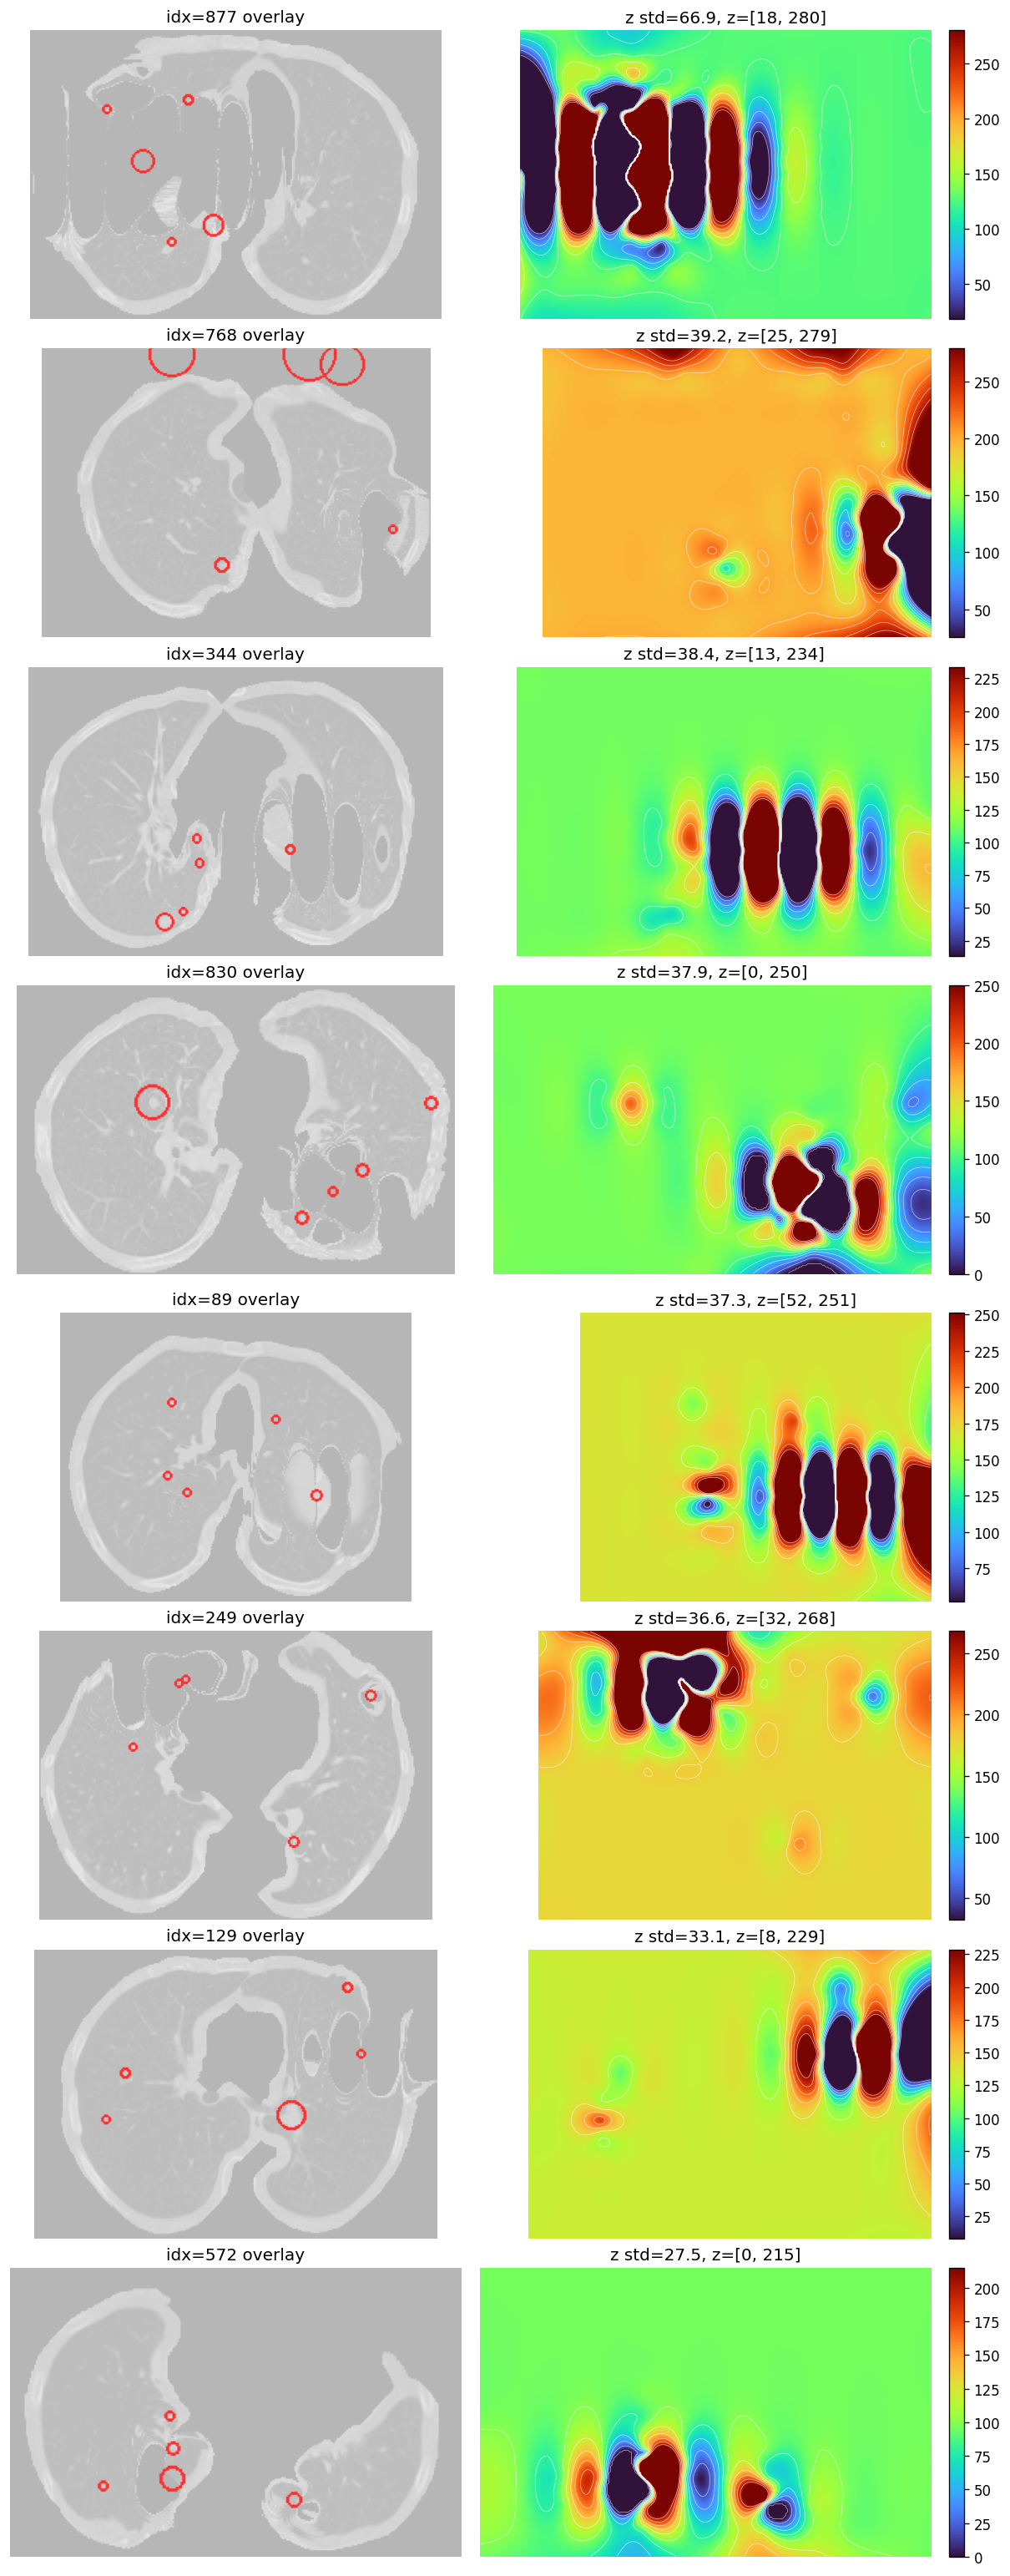

In [37]:
def show_worst_surfaces(n=12, sort_by="z_std"):
    rows = quality.sort_values(sort_by, ascending=False).head(n)
    cols = 3
    fig, axes = plt.subplots(len(rows), 2, figsize=(10, 3.2 * len(rows)), constrained_layout=True)
    if len(rows) == 1:
        axes = np.asarray([axes])
    for ax_pair, (_, row) in zip(axes, rows.iterrows()):
        image = load_array(row["synthetic_image"])
        overlay = load_overlay(row["overlay_image"])
        surface = load_array(row["z_surface"])
        ax_pair[0].imshow(overlay)
        ax_pair[0].set_title(f"idx={int(row['index'])} overlay")
        ax_pair[0].axis("off")
        im = ax_pair[1].imshow(surface, cmap="turbo")
        ax_pair[1].contour(surface, levels=12, colors="white", linewidths=0.4, alpha=0.7)
        ax_pair[1].set_title(f"z std={row['z_std']:.1f}, z=[{row['z_min']:.0f}, {row['z_max']:.0f}]")
        ax_pair[1].axis("off")
        plt.colorbar(im, ax=ax_pair[1], fraction=0.046, pad=0.04)
    plt.show()


show_worst_surfaces(n=8, sort_by="z_std")

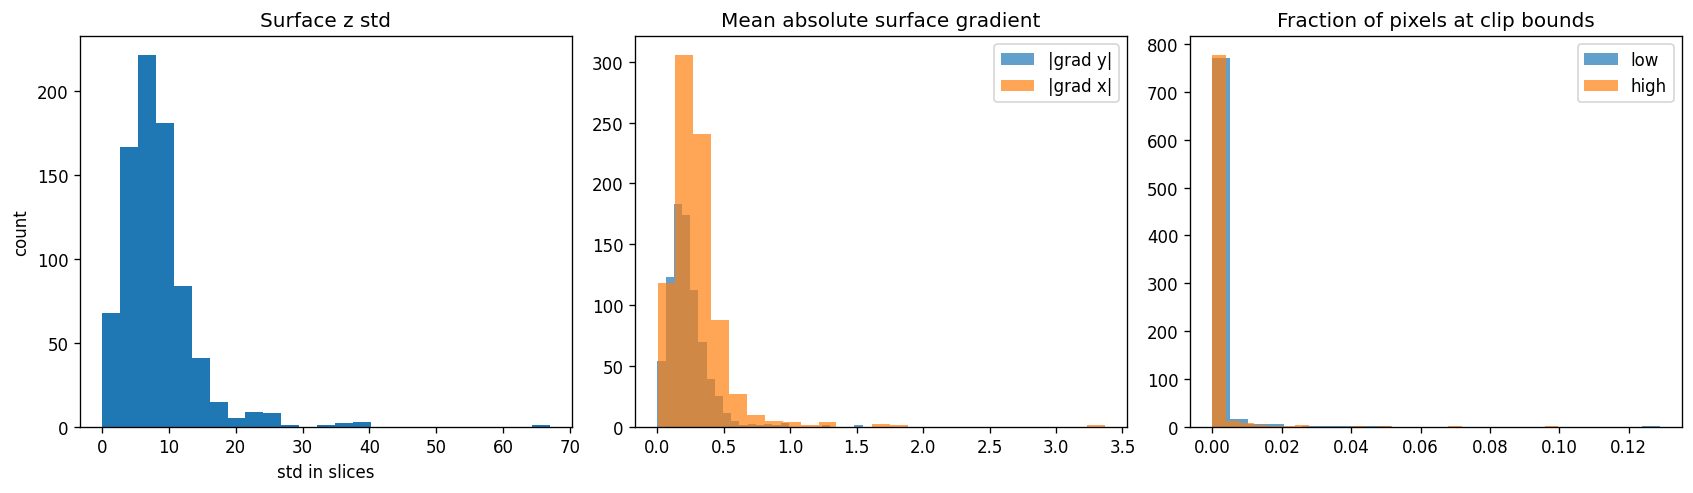

,z_std,mean_abs_grad_y,mean_abs_grad_x,clip_low_frac,clip_high_frac
count,808.000000,808.000000,808.000000,808.000000,808.000000
mean,8.320904,0.224872,0.297249,0.001008,0.000755
std,5.450876,0.143728,0.221959,0.006041,0.005399
min,0.075417,0.001876,0.002841,0.000000,0.000000
25%,5.158247,0.135500,0.179786,0.000000,0.000000
50%,7.516050,0.200200,0.264352,0.000000,0.000000
75%,10.242222,0.281479,0.365095,0.000000,0.000000
max,66.914970,1.544403,3.366247,0.128884,0.099694


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
axes[0].hist(quality["z_std"], bins=25)
axes[0].set_title("Surface z std")
axes[0].set_xlabel("std in slices")
axes[0].set_ylabel("count")

axes[1].hist(quality["mean_abs_grad_y"], bins=25, alpha=0.7, label="|grad y|")
axes[1].hist(quality["mean_abs_grad_x"], bins=25, alpha=0.7, label="|grad x|")
axes[1].set_title("Mean absolute surface gradient")
axes[1].legend()

axes[2].hist(quality["clip_low_frac"].fillna(0), bins=25, alpha=0.7, label="low")
axes[2].hist(quality["clip_high_frac"].fillna(0), bins=25, alpha=0.7, label="high")
axes[2].set_title("Fraction of pixels at clip bounds")
axes[2].legend()
plt.show()

quality[["z_std", "mean_abs_grad_y", "mean_abs_grad_x", "clip_low_frac", "clip_high_frac"]].describe()